In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd

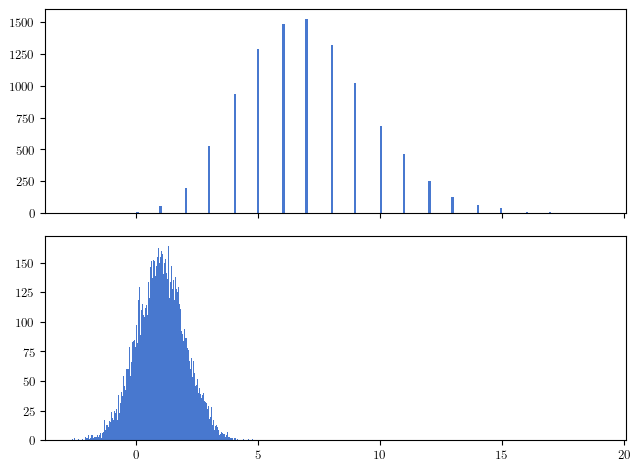

In [2]:
plt.style.use("seaborn-v0_8-muted")
def set_size(width_pt=472.31595, fraction=1, subplots=(1, 1)):
    """Set figure dimensions nicely

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** .5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return fig_width_in, fig_height_in

# Colormap with University colors
colors = ["white", "#005f9b", "#153268"]
nodes = [0.0, 0.8, 1.0]
unimap = matplotlib.colors.LinearSegmentedColormap.from_list("unimap", list(zip(nodes, colors)))
unimap_r = unimap.reversed()
try:
    matplotlib.colormaps.register(cmap=unimap)
    matplotlib.colormaps.register(cmap=unimap_r)
except ValueError:
    pass

# LaTeX text renderer
plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "font.serif": "Computer Modern Roman",
    "text.usetex": True,  # use inline math for ticks
    "text.latex.preamble": r"\usepackage{amsmath}",
    "pgf.rcfonts": False,  # don't setup fonts from rc parameters
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10.95,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Cmap
    "image.cmap": "unimap"
})
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=set_size(fraction=1, subplots=(1.2, 1)), sharex=True)

ax1.hist(np.random.poisson(7, 10000), bins=200)
ax2.hist(np.random.normal(1, 1, 10000), bins=200)

plt.tight_layout()
plt.show()
fig.savefig('style.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [3]:
import os
from collections import defaultdict

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['axes.prop_cycle'] = mpl.cycler(color=mpl.cm.Set2(range(8)))

/tmp/ipykernel_8350/38814280.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Set2')
/tmp/ipykernel_8350/38814280.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper right", frameon=False)
/tmp/ipykernel_8350/38814280.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="lower left", frameon=False)


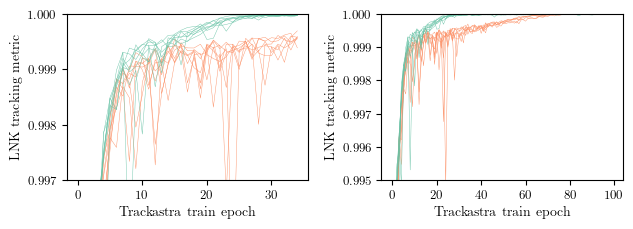

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(1, 2, figsize=set_size(fraction=1, subplots=(1.2, 2)))

cmap = mpl.cm.get_cmap('Set2')
num_colors = 7

colors = [cmap(i / num_colors) for i in range(num_colors)]
ca = colors[0]
cb = colors[1]

travals = dict()
for fname in os.listdir("effects/toiam/baseline/"):
    data = pd.read_csv(f"effects/toiam/baseline/{fname}")
    traval = data["TRA"][0]

    travals[fname] = traval

dd = defaultdict(dict)

for x in os.listdir("effects/toiam/baseline/"):
    dd["".join(x.split("_")[:-1])][int(x.split("_")[3].split(".")[0])] = travals[x]


for run_name in dd.keys():
    v = []
    for k in sorted(dd[run_name].keys()):
        v.append(dd[run_name][k])
    ax.flat[0].plot(v[:35], color=cb, linewidth=0.3)
    ax.flat[1].plot(v[:], color=cb, linewidth=0.3)


travals = dict()
for fname in os.listdir("effects/toiam/withembeddings/"):
    data = pd.read_csv(f"effects/toiam/withembeddings/{fname}")
    traval = data["TRA"][0]

    travals[fname] = traval

dd = defaultdict(dict)

for x in os.listdir("effects/toiam/withembeddings/"):
    dd["".join(x.split("_")[:-1])][int(x.split("_")[3].split(".")[0])] = travals[x]


for run_name in dd.keys():
    v = []
    for k in sorted(dd[run_name].keys()):
        v.append(dd[run_name][k])
    ax.flat[0].plot(v[:35], color=ca, linewidth=0.3)
    ax.flat[1].plot(v[:], color=ca, linewidth=0.3)

ax[0].set_xlabel("Trackastra train epoch")
ax[0].set_ylabel("LNK tracking metric")

ax[1].set_xlabel("Trackastra train epoch")
ax[1].set_ylabel("LNK tracking metric")
ax[1].legend(loc="upper right", frameon=False)
ax[0].legend(loc="lower left", frameon=False)

ax.flat[0].set_ylim(0.997, 1.0)
ax.flat[1].set_ylim(0.995, 1.0)

plt.tight_layout()

plt.savefig("embeddings_effect_toiam_rough.pdf")

/tmp/ipykernel_8350/768414488.py:154: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("Set2")


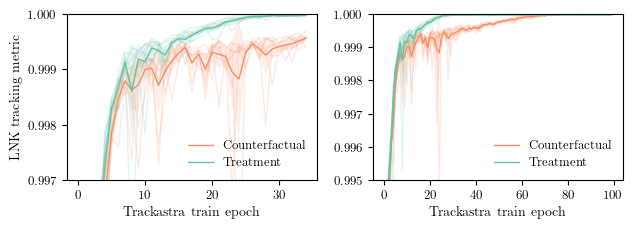

In [6]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib as mpl


# ---------------------------
# Helpers: load + aggregate
# ---------------------------
def load_series_from_dir(
    dirpath: str,
    value_col: str = "TRA",
    value_row: int = 0,
    key_from_filename=None,
):
    """
    Reads all CSVs in dirpath, extracts `data[value_col][value_row]`,
    and groups them into runs using `key_from_filename(fname)`.

    Returns:
      dd: dict[str, dict[int, float]] where dd[run_name][step] = value
    """
    if key_from_filename is None:
        # Your current filename convention:
        # dd["".join(x.split("_")[:-1])][int(x.split("_")[3].split(".")[0])] = value
        def key_from_filename(fname: str):
            parts = fname.split("_")
            run_name = "".join(parts[:-1])
            step = int(parts[3].split(".")[0])
            return run_name, step

    dd = defaultdict(dict)

    for fname in os.listdir(dirpath):
        if not fname.endswith(".csv"):
            continue
        data = pd.read_csv(os.path.join(dirpath, fname))
        v = float(data[value_col].iloc[value_row])

        run_name, step = key_from_filename(fname)
        dd[run_name][step] = v

    return dd


def dd_to_matrix(dd: dict, max_len=None):
    """
    Convert dd[run_name][step] into a matrix shape (n_runs, T) aligned by sorted steps.
    If runs have different step sets, missing values become NaN.
    """
    run_names = sorted(dd.keys())
    all_steps = sorted({s for rn in run_names for s in dd[rn].keys()})

    if max_len is not None:
        all_steps = all_steps[:max_len]

    step_to_idx = {s: i for i, s in enumerate(all_steps)}
    M = np.full((len(run_names), len(all_steps)), np.nan, dtype=float)

    for i, rn in enumerate(run_names):
        for step, val in dd[rn].items():
            if step in step_to_idx:
                M[i, step_to_idx[step]] = val

    return M, run_names, all_steps


def mean_and_ci(M, ci="sem", z=1.96):
    """
    M: (n_runs, T) with NaNs allowed.
    Returns mean, lo, hi (all length T).
    ci:
      - None: no band
      - "sem": mean ± z * (std/sqrt(n))
      - "std": mean ± z * std
      - float: quantile band (e.g., 0.1 => 10-90% band)
    """
    mean = np.nanmean(M, axis=0)

    if ci is None:
        return mean, None, None

    if ci == "sem":
        n = np.sum(~np.isnan(M), axis=0)
        std = np.nanstd(M, axis=0, ddof=0)
        sem = std / np.sqrt(np.maximum(n, 1))
        lo = mean - z * sem
        hi = mean + z * sem
        return mean, lo, hi

    if ci == "std":
        std = np.nanstd(M, axis=0, ddof=1)
        lo = mean - z * std
        hi = mean + z * std
        return mean, lo, hi

    if isinstance(ci, float) and 0.0 < ci < 0.5:
        lo = np.nanquantile(M, ci, axis=0)
        hi = np.nanquantile(M, 1.0 - ci, axis=0)
        return mean, lo, hi

    raise ValueError(f"Unsupported ci={ci}")


def plot_group_with_aggregate(
    ax,
    M,
    color,
    raw_alpha=0.18,
    raw_lw=1.0,
    agg_lw=1.0,
    band_alpha=0.15,
    ci="sem",
    label=None,
    highlight="best_last",  # None | "best_last" | "worst_last"
    highlight_lw=1,
):
    """
    Plots raw runs + mean curve + optional CI band + optional highlighted run.
    """
    # Raw runs
    for i in range(M.shape[0]):
        ax.plot(M[i, :], color=color, alpha=raw_alpha, lw=raw_lw)

    # Aggregate
    mean, lo, hi = mean_and_ci(M, ci=ci)
    ax.plot(mean, color=color, lw=agg_lw, label=label)

    if lo is not None and hi is not None:
        ax.fill_between(np.arange(len(mean)), lo, hi, color=color, alpha=band_alpha, linewidth=0)

    # Highlight one representative run (optional)
    if highlight in ("best_last", "worst_last") and M.shape[0] > 0:
        last_vals = M[:, -1]
        # handle NaN last values
        valid = ~np.isnan(last_vals)
        if np.any(valid):
            idxs = np.where(valid)[0]
            if highlight == "best_last":
                pick = idxs[np.argmax(last_vals[valid])]
            else:
                pick = idxs[np.argmin(last_vals[valid])]
            ax.plot(M[pick, :], "--", color=color, alpha=1.0, lw=highlight_lw)


# ---------------------------
# Your figure
# ---------------------------
fig, ax = plt.subplots(1, 2, figsize=set_size(fraction=1, subplots=(1.2, 2)))

cmap = mpl.cm.get_cmap("Set2")
num_colors = 7
colors = [cmap(i / num_colors) for i in range(num_colors)]
ca = colors[0]  # with embeddings
cb = colors[1]  # baseline


# Load baseline
dd_base = load_series_from_dir("effects/toiam/baseline/", value_col="TRA", value_row=0)
M_base_full, _, _ = dd_to_matrix(dd_base, max_len=None)
M_base_short, _, _ = dd_to_matrix(dd_base, max_len=35)

# Load with embeddings
dd_emb = load_series_from_dir("effects/toiam/withembeddings/", value_col="TRA", value_row=0)
M_emb_full, _, _ = dd_to_matrix(dd_emb, max_len=None)
M_emb_short, _, _ = dd_to_matrix(dd_emb, max_len=35)


# Left subplot (short horizon)
plot_group_with_aggregate(
    ax.flat[0], M_base_short, color=cb,
    ci="sem", label="Counterfactual", highlight=None
)
plot_group_with_aggregate(
    ax.flat[0], M_emb_short, color=ca,
    ci="sem", label="Treatment", highlight=None
)

# Right subplot (full horizon)
plot_group_with_aggregate(
    ax.flat[1], M_base_full, color=cb,
    ci="sem", label="Counterfactual", highlight=None
)
plot_group_with_aggregate(
    ax.flat[1], M_emb_full, color=ca,
    ci="sem", label="Treatment", highlight=None
)


# Match your limits
ax.flat[0].set_ylim(0.997, 1.0)
ax.flat[1].set_ylim(0.995, 1.0)

ax[1].set_xlabel("Trackastra train epoch")

ax[1].legend(loc="lower right", frameon=False)
ax[0].legend(loc="lower right", frameon=False)
ax[0].set_xlabel("Trackastra train epoch")
ax[0].set_ylabel("LNK tracking metric")

fig.tight_layout()
plt.savefig("toiam.pdf")


# OLD

/tmp/ipykernel_8350/1315334911.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Set2')


NameError: name 'withs' is not defined

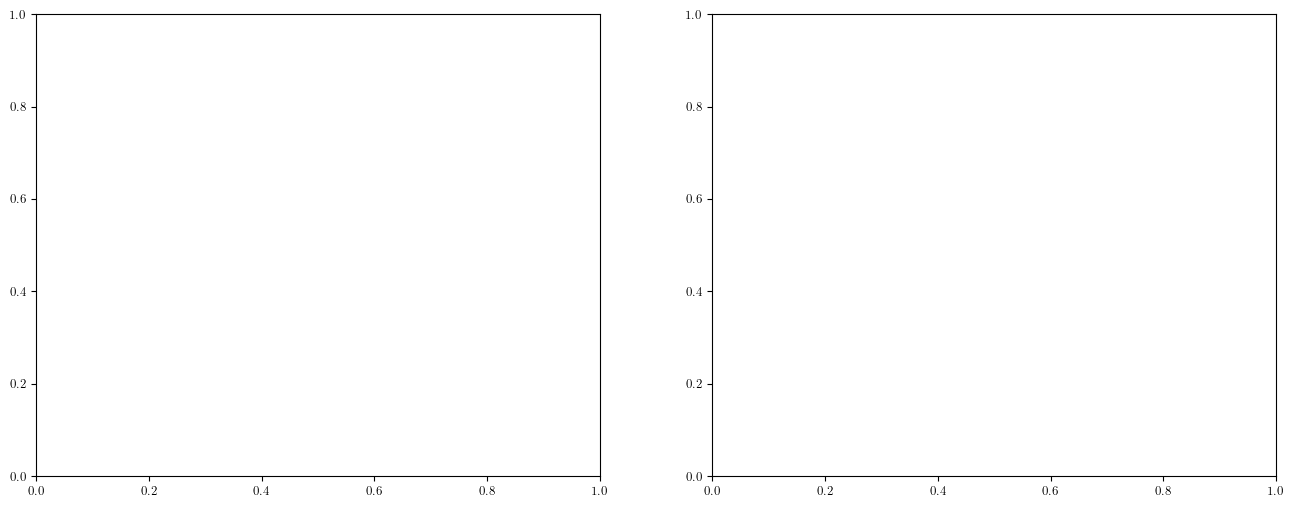

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(1,2, figsize=(16,6))

cmap = mpl.cm.get_cmap('Set2')
num_colors = len(withs) + len(withouts)

colors = [cmap(i / num_colors) for i in range(num_colors)]
ca = colors[0]
cb = colors[2]

for s in withs:
    ax.flat[0].plot(s[:20], 
                    )

for s in withouts:
    ax.flat[0].plot(s[:20], color=cb)


ax.flat[0].set_ylim(bottom=0.98)

for s in withs:
    ax.flat[1].plot(s[:], color=ca)

for s in withouts:
    ax.flat[1].plot(s[:], color=cb)
    


ax.flat[1].set_ylim(bottom=0.90)

fig.tight_layout()
plt.savefig("embeddings_effect_fluo_rough.pdf")


NameError: name 'withs' is not defined

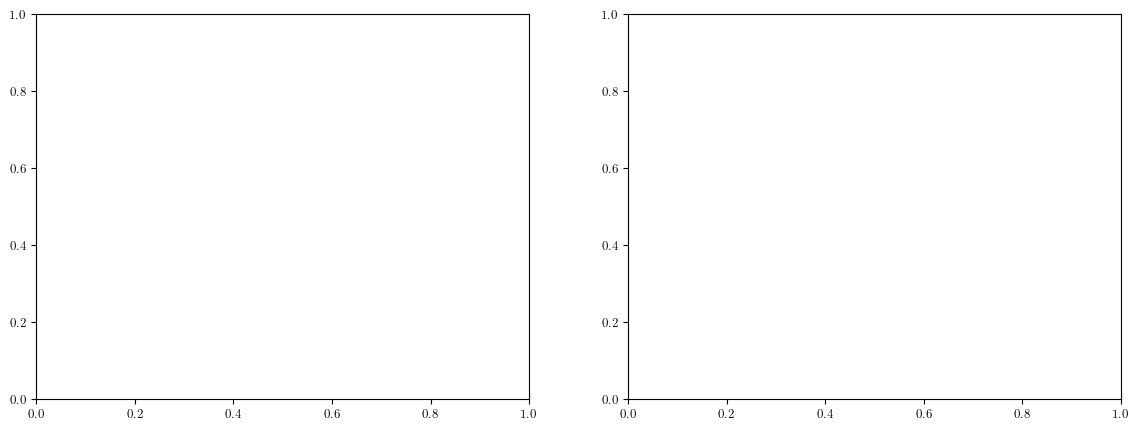

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(1, 2, figsize=(14,5))

cmap = mpl.colormaps['Set2']
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, data, color, label, maxlen=None):
    arr = np.array([d[:maxlen] for d in data])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)

    x = np.arange(len(mean))
    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean-std, mean+std, color=color, alpha=0.25)

# left: zoomed (first 20)
plot_mean_shaded(ax[0], withs, ca, "With", maxlen=20)
plot_mean_shaded(ax[0], withouts, cb, "Without", maxlen=20)
ax[0].set_ylim(0.98, 1.0)
ax[0].legend()

# right: entire sequence
plot_mean_shaded(ax[1], withs, ca, "With")
plot_mean_shaded(ax[1], withouts, cb, "Without")
ax[1].set_ylim(0.90, 1.0)
ax[1].legend()

fig.tight_layout()
plt.savefig("embeddings_effect_fluo_aggregated.pdf")


### Significance over time

In [9]:
from scipy import stats

pvals = []

for idx in range(len(withs[0])):

    w = [x[idx] for x in withs]
    wo = [x[idx] for x in withouts]

    res = stats.ttest_ind(w, wo)

    
    pval = res.pvalue

    pvals.append(pval)

NameError: name 'withs' is not defined

/home/constantin/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


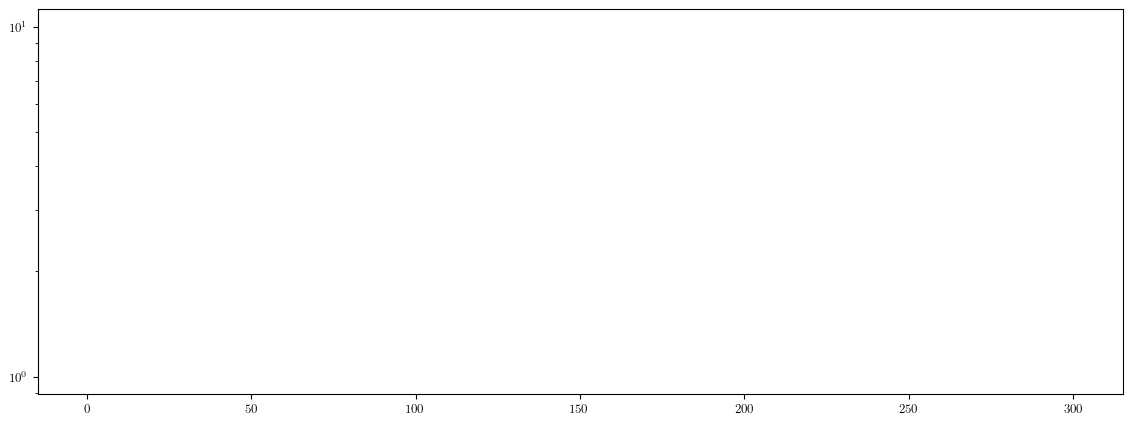

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(14,5))

x = np.arange(len(pvals))
ax.bar(x, pvals)
ax.set_yscale('log')
ax.hlines(0.05, 0, 300, color='orange') # 0.05
ax.hlines(0.027, 0, 300, color='red') # 3 sigma

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# === colors & helper from your code ===
cmap = mpl.colormaps['Set2']
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, data, color, label, maxlen=None):
    arr = np.array([d[:maxlen] for d in data])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)

    x = np.arange(len(mean))
    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean-std, mean+std, color=color, alpha=0.25)

# === compute p-values (same logic as your second snippet) ===
pvals = []
for idx in range(len(withs[0])):
    w  = [x[idx] for x in withs]
    wo = [x[idx] for x in withouts]

    res = stats.ttest_ind(w, wo)  # or equal_var=False if you prefer Welch’s test
    pvals.append(res.pvalue)

pvals = np.array(pvals)
x = np.arange(len(pvals))

# === combined figure: top = full plot, bottom = significance ===
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# --- TOP: full sequence (what you had on the right) ---
plot_mean_shaded(ax_top, withs, ca, "With")
plot_mean_shaded(ax_top, withouts, cb, "Without")
ax_top.set_ylim(0.90, 1.0)
ax_top.set_ylabel("Score")   # adjust to your metric name
ax_top.legend()

# --- BOTTOM: p-values over time ---
ax_bottom.bar(x, pvals)
ax_bottom.set_yscale('log')

# horizontal lines for thresholds (use x.min()/x.max() to match the data length)
xmin, xmax = x.min(), x.max()
ax_bottom.hlines(0.05,  xmin, xmax, color='orange', linestyle='--', label='p = 0.05')
ax_bottom.hlines(0.027, xmin, xmax, color='red',    linestyle='--', label='p = 0.027')  # 3σ approx?

ax_bottom.set_ylabel("p-value (log)")
ax_bottom.set_xlabel("Time step / index")
ax_bottom.legend(loc="upper right")

fig.tight_layout()
plt.savefig("fluo_with_without_plus_significance.pdf", bbox_inches='tight')
plt.show()


NameError: name 'withs' is not defined